# Pipeline for labeling the real-world data files

Data collection followed the procedure of firstly performing a standardized protocol - same as that of the prelim data collection, afterwards a trip into halls were real tasks were performed in a real life work setting. A lot of the work is therefore to find meaningful labeling strategies for the real world data.

Notes to self about what i want to find out:
- is it okay to sample IMUs at 100Hz?
- when did the insoles cut out in the sessions where that happened?
- check for domain shift from protocol lab data collected at NTNU vs AKSO participants
- how on earth do we label the real world data?

In [2]:
# Imports
from pre_processing.labeling import detect_spikes, init_label, plot_signal_peaks, extract_activity_windows, apply_corrected_labels, extract_pressure_data, remove_idle, sort_push_pull
from pre_processing.fiks_time_muse import make_df, check_samples, fix_time_muse_hz
from pre_processing.clean_mitch_timestamps import remove_end_duplicates, add_ReconstructedTime
from pre_processing.filter_sensor_data import median_filter_medfilt
from pre_processing.segment_repetition_vol2 import plot_activity_accelerations_peaks_and_magnitude, get_start_stop_times_from_peaks, assign_rep_ids
from pre_processing.label_hall import add_label
from plotting.plot_sensor_signals import plot_all_sensors, plot_fsr, plot_single_imu
from utils import get_imu_cols, get_fsr_cols, get_nearest_row_by_time

from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

### Step 1: time sync and separate protocol from real life data
Then label protocol data through the standard pipeline!

In [ ]:
# First load the raw sensor files 
base_dir = Path(r"C:\Users\Bruker\Data_msc26_prelim")
participant_dir_name = "akso_4"

data_dir = base_dir / participant_dir_name

raw_larm = data_dir / "Muse_E2511_RED-ARM_LEFT.txt"
raw_rarm = data_dir / "Muse_E2511_GREY-ARM_RIGHT.txt"
raw_lb = data_dir / "muse_v3_3-LB.txt"
raw_ub = data_dir / "muse_v3-UB.txt"
raw_lsole = data_dir / "mitch_B0308-LEFT.txt"
raw_rsole = data_dir / "mitch_B0510-RIGHT.txt"

output_dir = data_dir

In [ ]:
# Then plot the data. Should be able to see from left arm IMU where standard protocol ands and new protocol starts
df_plot_list = make_df(muse_file_1=str(raw_rarm), muse_file_2=str(raw_larm), muse_file_3=str(raw_lb), muse_file_4=str(raw_ub), mitch_file_1=str(raw_lsole), mitch_file_2=str(raw_rsole))


plot_all_sensors(
    df_plot_list, 
    time_mode='index', 
    names = ['right arm', 'left arm',  'left insole', 'right insole', 'low back', 'upper back'],
    )


In [ ]:
# Fix time Muse sensors
df_list = make_df(muse_file_1=str(raw_rarm), muse_file_2=str(raw_larm), muse_file_3=str(raw_lb), muse_file_4=str(raw_ub)) # a list containing one element in this case...
samples, time = check_samples(df_list)
print(df_list[2])

print("Samples:", samples)
print("Time:", time)

fixed_time_rarm = fix_time_muse_hz(df_list, 0, str(raw_rarm), 100) # 800 is the sampling frequency
fixed_time_larm = fix_time_muse_hz(df_list, 1, str(raw_larm), 100) # 800 is the sampling frequency
fixed_time_lb = fix_time_muse_hz(df_list, 4, str(raw_lb), 100) # 800 is the sampling frequency
fixed_time_ub = fix_time_muse_hz(df_list, 5, str(raw_ub), 100) # 800 is the sampling frequency

# New .csv is saved to directory where the raw sensor data file resides. Path is stored in fixed_time_{whatever sensor} variables


In [ ]:
# Fix Mitch time
df_dupli_left, outpath_dupli_left = remove_end_duplicates(str(raw_lsole))
df_dupli_right, outpath_dupli_right = remove_end_duplicates(str(raw_rsole))

df_time_left, outpath_time_left = add_ReconstructedTime(outpath_dupli_left, df_dupli_left)
df_time_right, outpath_time_right = add_ReconstructedTime(outpath_dupli_right, df_dupli_right)

In [ ]:
# Detect peaks in left arm and plot acceleration!
# Define the split peak as the one at hall entry. So that is the first true peak after the final stairs one.
# Save that timestamp to a variable. Standard is it should be peak number -2, but that may differ so verify, verify, verify 
# When in doubt split at the earliest pek and check later...
peak_df, peaks = detect_spikes(fixed_time_larm)
init_label_df = init_label(peak_df, peaks, fixed_time_larm)
plot_signal_peaks(init_label_df, peaks) 

In [ ]:
print(peaks[-5])

In [ ]:
split_peak = peaks[-5] # manually select split peak here

# find seconds mark for split:
df_larm_fixed = pd.read_csv(fixed_time_larm)
df_rarm_fixed = pd.read_csv(fixed_time_rarm)
df_ub_fixed = pd.read_csv(fixed_time_ub)
df_lb_fixed = pd.read_csv(fixed_time_lb)

print(df_larm_fixed['ReconstructedTime'].iloc[split_peak])
print(df_rarm_fixed['ReconstructedTime'].iloc[split_peak])
print(df_ub_fixed['ReconstructedTime'].iloc[split_peak])
print(df_lb_fixed['ReconstructedTime'].iloc[split_peak])
print(df_time_left['ReconstructedTime'].iloc[split_peak//8])
print(df_time_right['ReconstructedTime'].iloc[split_peak//8]) # divide by eight to counteract sampling rate differences


t_ref = df_larm_fixed["ReconstructedTime"].iloc[split_peak]

row_time_left  = get_nearest_row_by_time(df_time_left,  t_ref)
row_time_right = get_nearest_row_by_time(df_time_right, t_ref)
print(row_time_left['ReconstructedTime'])
print(row_time_right['ReconstructedTime'])

In [ ]:
# Split!

# LARM
df_larm_before = df_larm_fixed.iloc[:split_peak]
df_larm_after  = df_larm_fixed.iloc[split_peak+1:]

# RARM
df_rarm_before = df_rarm_fixed.iloc[:split_peak]
df_rarm_after  = df_rarm_fixed.iloc[split_peak+1:]

# UB
df_ub_before = df_ub_fixed.iloc[:split_peak]
df_ub_after  = df_ub_fixed.iloc[split_peak+1:]

# LB
df_lb_before = df_lb_fixed.iloc[:split_peak]
df_lb_after  = df_lb_fixed.iloc[split_peak+1:]

# Soles
df_lsole_before = df_time_left.iloc[:row_time_left.name]
df_lsole_after = df_time_left.iloc[row_time_left.name+1:]

df_rsole_before = df_time_right.iloc[:row_time_right.name]
df_rsole_after = df_time_right.iloc[row_time_right.name+1:]

In [ ]:
dfs_before = [df_rarm_before, df_larm_before, df_lsole_before, df_rsole_before, df_lb_before, df_ub_before]
dfs_after = [df_rarm_after, df_larm_after, df_lsole_after, df_rsole_after, df_lb_after, df_ub_after]


plot_all_sensors(dfs=dfs_before, time_mode='ReconstructedTime', 
                 names = ['Right arm before', 'Left arm before', 'Left sole before', 'Right sole before', 'Lower back before', 'Upper back before'])

plot_all_sensors(dfs=dfs_after, time_mode='ReconstructedTime', 
                 names = ['Right arm after', 'Left arm after', 'Left sole after', 'Right sole after', 'Lower back after', 'Upper back after'])


In [ ]:
# save files
# LARM
df_larm_before.to_csv(data_dir / "left_arm_protocol_reconst_time.csv", index=False)
df_larm_after.to_csv(data_dir / "left_arm_hall_reconst_time.csv", index=False)

# RARM
df_rarm_before.to_csv(data_dir / "right_arm_protocol_reconst_time.csv", index=False)
df_rarm_after.to_csv(data_dir / "right_arm_hall_reconst_time.csv", index=False)

# UB
df_ub_before.to_csv(data_dir / "upper_back_protocol_reconst_time.csv", index=False)
df_ub_after.to_csv(data_dir / "upper_back_hall_reconst_time.csv", index=False)

# LB
df_lb_before.to_csv(data_dir / "lower_back_protocol_reconst_time.csv", index=False)
df_lb_after.to_csv(data_dir / "lower_back_hall_reconst_time.csv", index=False)

# TIME LEFT
df_lsole_before.to_csv(data_dir / "left_sole_protocol_reconst_time.csv", index=False)
df_lsole_after.to_csv(data_dir / "left_sole_hall_reconst_time.csv", index=False)

# TIME RIGHT
df_rsole_before.to_csv(data_dir / "right_sole_protocol_reconst_time.csv", index=False)
df_rsole_after.to_csv(data_dir / "right_sole_hall_reconst_time.csv", index=False)

### Begin labeling the hall data here...
If you have already split, then just begin here :))

In [150]:
# start by reading the sensor files

# redefine base dir  and data dir and read the files from there
base_dir = Path(r"C:\Users\johalot\msc_data")
participant_dir_name = "akso_4"

data_dir = base_dir / participant_dir_name


df_rarm = pd.read_csv(data_dir / 'right_arm_hall_reconst_time.csv')
df_larm = pd.read_csv(data_dir / 'left_arm_hall_reconst_time.csv')
df_lb = pd.read_csv(data_dir / 'lower_back_hall_reconst_time.csv')
df_ub = pd.read_csv(data_dir / 'upper_back_hall_reconst_time.csv')
df_lsole = pd.read_csv(data_dir / 'left_sole_hall_reconst_time.csv')
df_rsole = pd.read_csv(data_dir / 'right_sole_hall_reconst_time.csv')


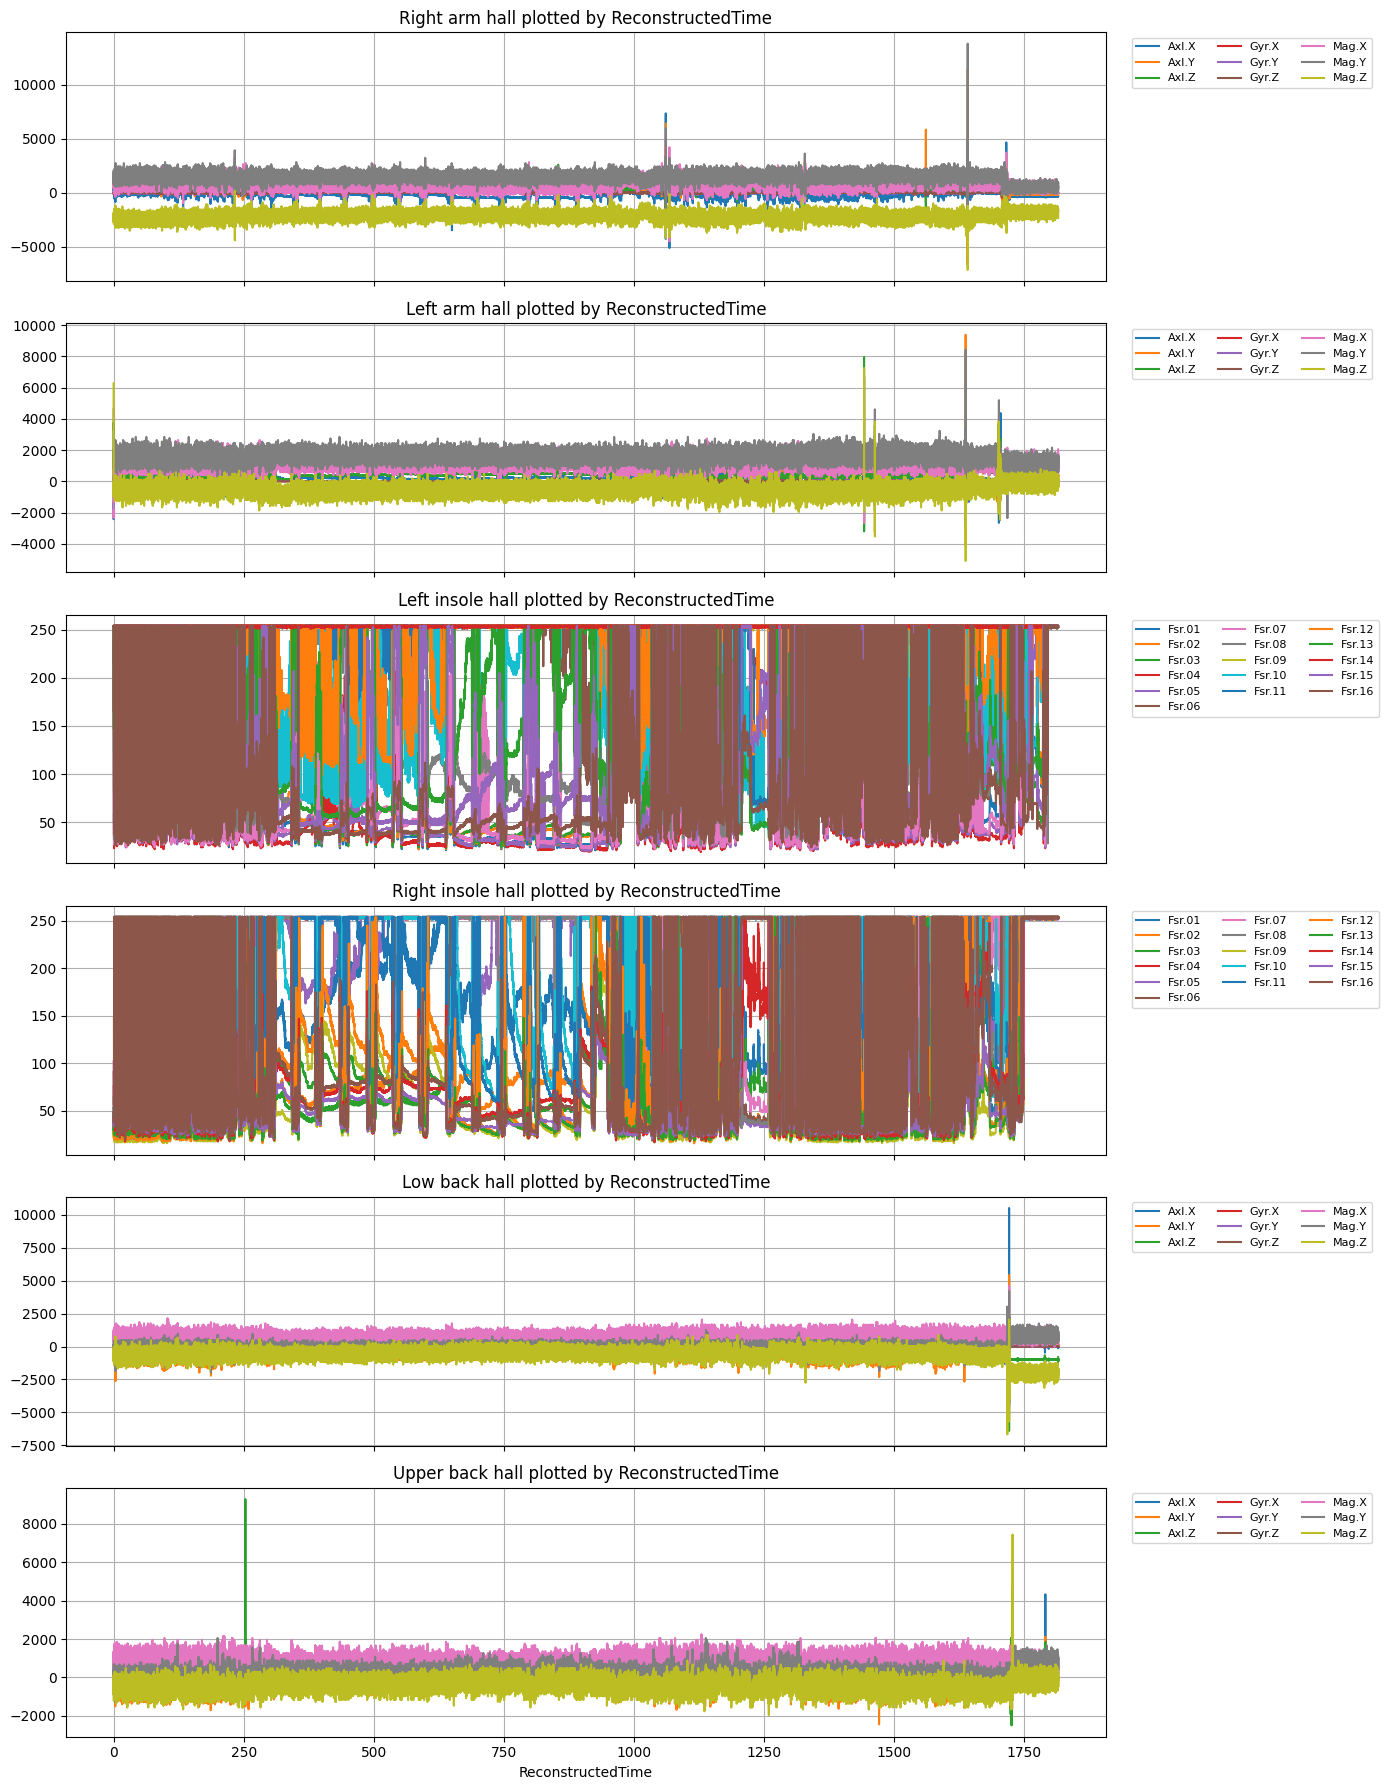

In [151]:
df_plot_list = [df_rarm, df_larm, df_lsole, df_rsole, df_lb, df_ub]


plot_all_sensors(
    df_plot_list, 
    time_mode='ReconstructedTime', 
    names = ['Right arm hall', 'Left arm hall',  'Left insole hall', 'Right insole hall', 'Low back hall', 'Upper back hall'],
    )

In [156]:
# redo time fix to get corresponding start time to start of hall session, i.e. hall session starts at t=0

df_list = [df_rarm, df_larm, df_lsole, df_rsole, df_lb, df_ub]

fixed_time_rarm = fix_time_muse_hz(df_list, 0, str(data_dir / 'right_arm_hall_reconst_time.csv'), 100) # 800 is the sampling frequency
fixed_time_larm = fix_time_muse_hz(df_list, 1, str(data_dir / 'left_arm_hall_reconst_time.csv'), 100) # 800 is the sampling frequency
fixed_time_lb = fix_time_muse_hz(df_list, 4, str(data_dir / 'lower_back_hall_reconst_time.csv'), 100) # 800 is the sampling frequency
fixed_time_ub = fix_time_muse_hz(df_list, 5, str(data_dir / 'upper_back_hall_reconst_time.csv'), 100) # 800 is the sampling frequency

df_time_left, outpath_time_left = add_ReconstructedTime( str(data_dir / 'left_sole_hall_reconst_time.csv'), df_list[2])
df_time_right, outpath_time_right = add_ReconstructedTime(str(data_dir / 'right_sole_hall_reconst_time.csv'), df_list[3])

Sample number: 185896
Recorded time sec: 1815.381
Recorded time min: 30.25635
Sample number: 185947
Recorded time sec: 1815.879
Recorded time min: 30.26465


In [157]:
# make dfs from paths and define list for plotting.
fixed_time_rarm_df = pd.read_csv(fixed_time_rarm)
fixed_time_larm_df = pd.read_csv(fixed_time_larm)
fixed_time_lb_df = pd.read_csv(fixed_time_lb)
fixed_time_ub_df = pd.read_csv(fixed_time_ub)

plot_df_list = [fixed_time_rarm_df, fixed_time_larm_df, df_time_left, df_time_right, fixed_time_lb_df, fixed_time_ub_df]
plot_names = ['Right arm', 'Left arm', 'Left sole', 'Right sole', 'Lower back', 'Upper back']

### Label!
Go through the plot in segments, call add_label, to define a new label segment  by time. 

Start time in seconds 1331
End time in seconds 1370


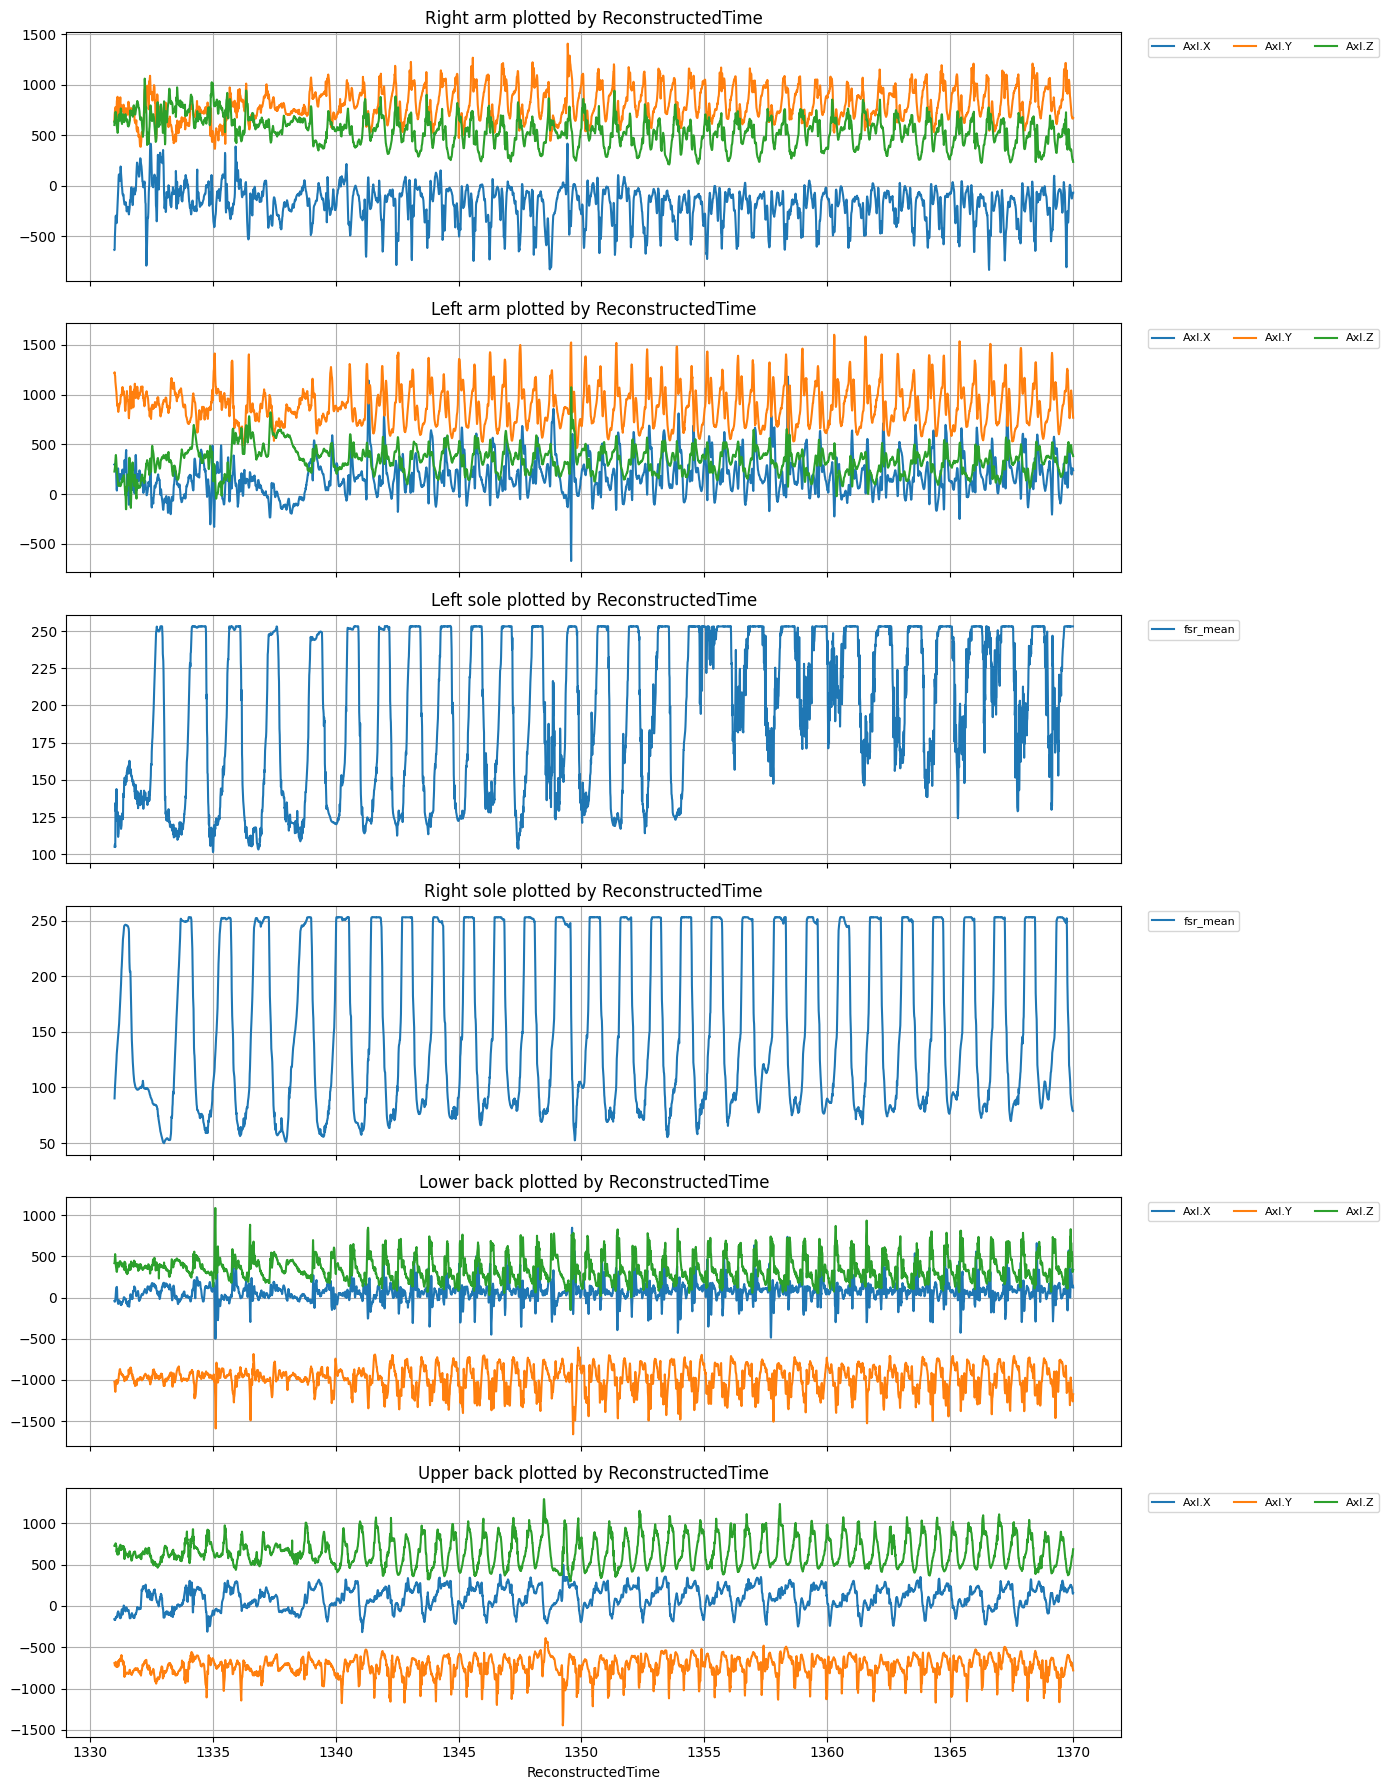

In [347]:
# define start and stop seconds for plot windows based on session notes. Notes are typically taken in minutes, so convert to seconds.
start_time_mins = 22
start_time_secs = 11
t_start = start_time_mins*60 + start_time_secs

end_time_mins = 22
end_time_secs = 50

t_end = end_time_mins*60 + end_time_secs
#t_end = 1136

print('Start time in seconds', t_start)
print('End time in seconds', t_end)

plot_all_sensors(dfs=plot_df_list,
                 time_mode = 'ReconstructedTime',
                 names=plot_names,
                 t_start=t_start, 
                 t_end=t_end,
                 imu_components=['Axl'],
                 fsr_mode='Mean')




In [348]:
add_label(
    data_dir=data_dir,
    label='walk_carry',
    start_time=1331,
     end_time=1370
)


Label 'walk_carry' added (1331s → 1370s)


### Apply labels from timestamp .csv file

In [349]:
# init label column

fixed_time_larm_df['label'] = None
fixed_time_rarm_df['label'] = None
fixed_time_ub_df['label'] = None
fixed_time_lb_df['label'] = None

df_time_left['label'] = None
df_time_right['label'] = None

In [350]:
def apply_time_labels(sensor_df, labels_df, time_col="ReconstructedTime"):
    """
    Apply interval labels to a dataframe based on time column.
    Returns a copy with an updated label column
    """

    df = sensor_df.copy()

    for _, row in labels_df.iterrows():
        mask = (df[time_col] >= row["start_time"]) & (df[time_col] <= row["end_time"])
        df.loc[mask, "label"] = row["label"]

    return df

In [351]:
labels_df = pd.read_csv(data_dir / 'hall_labels_start_stop.csv')

fixed_time_larm_df = apply_time_labels(fixed_time_larm_df, labels_df)
fixed_time_rarm_df = apply_time_labels(fixed_time_rarm_df, labels_df)
fixed_time_ub_df   = apply_time_labels(fixed_time_ub_df, labels_df)
fixed_time_lb_df   = apply_time_labels(fixed_time_lb_df, labels_df)

df_time_left  = apply_time_labels(df_time_left, labels_df)
df_time_right = apply_time_labels(df_time_right, labels_df)

In [352]:
df_time_left["label"].unique()

array([None, 'walking', 'forward_lean', 'break',
       'break_putting_on_equipment', 'bend_down', 'stair_ladder',
       'static_sideways_lean_left', 'welding_sideways_lean_left',
       'standing_break_right_arm_brush', 'welding_lean_left_backwards',
       'break_twist_left_brush_right_arm', 'welding_backward_lean',
       'break_right_arm_brush', 'welding_upright_forward_lean',
       'break_brush_right_arm', 'welding_arms_forward',
       'welding_forward_lean', 'break_standing_right_arm_brush',
       'break_brush_right', 'welding_forward_left_lean',
       'break_right_arm_brush_twist', 'standing_hammer_right_arm',
       'forward_left_lean_welding', 'welding_forward_lean_left',
       'stairs_down', 'stairs_up',
       'grinding_torso_twist_right_arms_forward', 'grinding_forward',
       'forward_bend', 'bend_down_lift_right', 'carry_right',
       'lift_both_arms', 'forward_lean_dynamic_arms',
       'sitting_on_knees_dynamic_arms', 'arms_up',
       'lift_onto_shoulder_right'

In [353]:
# save to new .csv files
fixed_time_larm_df.to_csv(data_dir / 'left_arm_hall_reconst_time_labeled.csv')
fixed_time_rarm_df.to_csv(data_dir / 'right_arm_hall_reconst_time_labeled.csv')
fixed_time_lb_df.to_csv(data_dir / 'lower_back_hall_reconst_time_labeled.csv')
fixed_time_ub_df.to_csv(data_dir / 'upper_back_hall_reconst_time_labeled.csv')

df_time_left.to_csv(data_dir / 'left_sole_hall_reconst_time_labeled.csv')
df_time_right.to_csv(data_dir / 'right_sole_hall_reconst_time_labeled.csv')